# Nautilus Introduction #

by Quinn Blackstone, Aniruddh Chalagulla, Eshel Dror and Niklas Naworal  (2026)

This is a tutorial for using the [Nautilus](https://arxiv.org/abs/2306.16923) sampler in `orbitize`!

In [1]:
import orbitize
import numpy as np
import multiprocessing as mp

## Basic Orbit Generating

Before we get on with orbit generation, lets get some data ready. Already have a file? Lets convert it into a format the sampler can understand.

In [2]:
from orbitize.read_input import read_file
data_table = read_file('{}/GJ504.csv'.format(orbitize.DATADIR)) # path to data file, now we can input this data into the sampler

Not done yet, you have to put everyting together.

In [3]:
from orbitize import system

Now put all the data and parameters together:

In [4]:
mySys = system.System(
        1, # number of bodies in your system (int)
        data_table, # the data you got previously (table)
        1.22, # mass of the system (float)
        56.95, # paralax (float)
        0, # mass err (int)
        0, # plx err (int) 
        )

This is cool and all but if we run the sampler on this data, it's going to take time. I'm a tutorial we don't have time for that, instead lets generate some synthetic data with the `generate_synthetic_data()` function

Cool thing about this function is that it calculates the semi major axis for you

In [5]:
from orbitize.system import generate_synthetic_data

In [6]:
data_table, sma = generate_synthetic_data(
    95, # orbital fraction, how much of the orbit is covered (0-100%)
    1.2, # mass of the system
    60, # paralax
    0.1, # eccentricity (float)
    np.pi/6, # inclination (float)
    unc=2, # uncertainty (int)
    num_obs=30, # number of observations to be made (int)
)

In [7]:
mySys = system.System(1, data_table, 1.2, 60)

Initialize the sampler

In [8]:
from orbitize import sampler

In [9]:
mysampler = sampler.NautilusSampler(mySys)

Nice, now it's time to run the sampler

A bit more on the hyperparameters

Sampler arguments-
n_networks: The number of neural networks trained to determine the iso-likelihood shells at each iteration. The likelihood scores prediceted by the neural networks are averaged to determine if a point is included in a shell. A higher value of n_networks leads to greater sampling efficiency at the cost of higher overhead per iteration. Neural network training is not parallelized.
n_batch: The number of orbits evaluated in each iteration, must be a multiple of num_threads. Each thread evaluates a set of n_batch/num_threads orbits. Higher n_batch takes advantage of the vectorized prior transform to improve computation speed, at the cost of some extra likelihood evaluations being performed in each shell (i.e. if n_update is 2500 samples and n_batch is 1000 then 3000 samples would be taken).

Run arguments-
f_live: The maximum fraction of the evidence left in the live set before switching from the exploration to the sampling phase. This can be used to act as an ending point for the exploration phase (when shells are created), larger values lead to faster convergence but may not converge fully.
n_eff: The total effective size of the sample. Larger values produce higher quality posterior estimations but take longer to run. Acts as the ending point of the sampling phase.

n_live: Number of live points used in the sampling process. Greater n_live yields better evidence estimation and shell accuracy but increased run time and computational cost.
num_threads: Number of threads used in parallel, greater number increases speed.
n_update: Number of additions to the live set before creating a new shell. If None defaults to n_live. Greater n_update leads to better shell accuracy but increased run time.
verbose: Lets you choose wether or not to display live updates of the sampler.
savefile: The name for a file that you want to save or resume nautilus progress to or from.

See more on the possible hyperparameters in the [Nautilus docs](https://nautilus-sampler.readthedocs.io/en/latest/api_full.html)

In [10]:
sampler_arg = {
    "n_networks": 4,
    "n_batch": None, #(int)  
    }
run_arg = {"f_live": 0.01, "n_eff": 1000} 
samples = mysampler.run_sampler(
        n_live=500, #(int)
        num_threads=mp.cpu_count(), #(int)
        n_update=None, #(int)
        verbose=True, #(bool) 
        savefile=None, #(str)
        sampler_kwargs=sampler_arg,
        run_kwargs=run_arg
    )

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 49     | 1        | 4        | 113100   | N/A    | 4503  | -166.17  


## Plotting and results ##

For a more detailed guide on data visualization capabilities within orbitize, see the [Orbitize plotting tutorial](https://orbitize.readthedocs.io/en/latest/tutorials/Plotting_tutorial.html).

After generating the samples, the `run_sampler` method also creates a `Results` object that can be accessed
with `mysampler.results`:

In [11]:
myResults = mysampler.results

### Weighted results

What is the difference between post and weighted post?
Weighted results are all the points that have been sampled by Nautilus weighted by shell sampling density and likelihood. The main benefit of weighted results is that they contain all points instead of equal-weighted results which are downsampled from it with no duplicates. plot_corner is able to make use of the weighted results for better accuracy but plot_orbits is not and therefore defaults to the unweighted results.

myResults.weighted_post returns weighted posteriors if it exists, and unweighted if it does not, so you can still get the posterior from Nautilus without weights.
myResults.weighted_lnlike functions similarly for getting the log-likelihoods

myResults.post is always unweighted. The same goes for myResults.lnlike.
Weight can be acquired from myResults.weight

In [12]:
myResults.post.shape

(1954, 8)

In [13]:
myResults.weighted_post.shape

(111635, 8)

In case you want more points than that of the unweighted results but fewer points than the weighted, you can use the downsample function. Note that if you do not allow duplicates, you will not obtain a completely true posterior (especially if your `amount` approaches the weighted posterior size); if you want a true equal-weighted posterior without duplicates use myResults.post.

In [14]:
# Samples from the posterior a number of times. If the posterior is weighted, samples proportionally to weight to get an equal-weighted posterior.
post, lnlike = myResults.downsample(
                     150000, # amount
                     True # allow duplicates
                                    )
post.shape, lnlike.shape

((150000, 8), (150000,))

You might be wondering what kind of cases you might want duplicates to be true, it would be when you want more points.
For example this would return an error:

In [15]:
try:
    post, lnlike = myResults.downsample(250000, duplicates=False)
    print(post.shape, lnlike.shape)

except ValueError as error:
    print(f"Downsampling error: {error}")

Downsampling error: Cannot take a larger sample than population when 'replace=False'


In addition to our `orbits` array, Orbitize also creates a `Results` class that contains built-in plotting capabilities for two types of plots: corner plots and orbit plots. These cornerplots can also take in weighted results, in addition to downsizing them.

### Corner Plot ###

We can now create a corner plot using the function `plot_corner` within the `Results` class. This function requires an input list of the parameters, in string format, that you wish to include in your corner plot. We can even plot all of the orbital parameters at once! You may wish to use the `downsample` keyword if you want a quick graph as the full weighted posteriors tend to take a while to plot. As shown below:

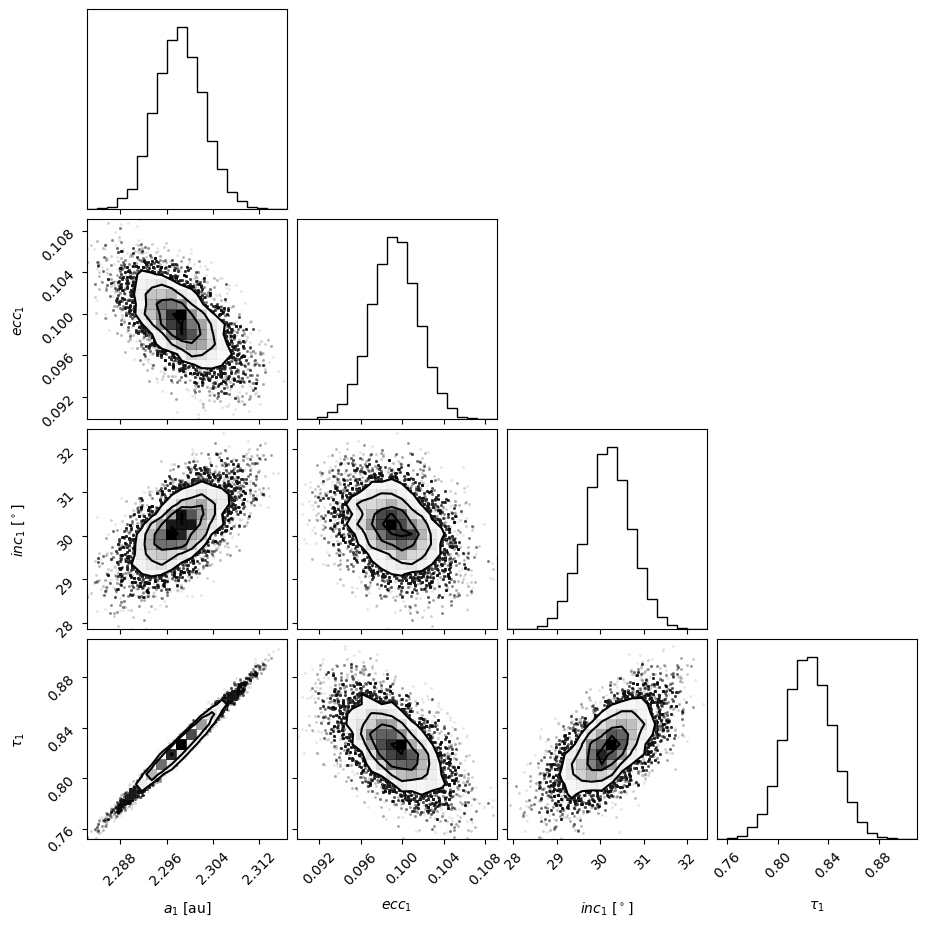

In [16]:
corner_figure = myResults.plot_corner(downsample=100000,param_list=['sma1', 'ecc1', 'inc1','tau1'])

Find out more about generating orbits in ``orbitize!`` with tutorials [here](https://orbitize.readthedocs.io/en/latest/tutorials.html).